<a href="https://colab.research.google.com/github/tiwarisubash956/Machine-Learning-Algorithms/blob/main/Kmeansalgorithm_scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [37]:
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import random
import numpy as np

In [38]:
cluster_std=[1,1,1]
centroid=[(-5,-5),(5,5),(-2.3,-2.5)]
X,y=make_blobs(n_samples=100,centers=centroid,cluster_std=cluster_std,n_features=2,random_state=2)


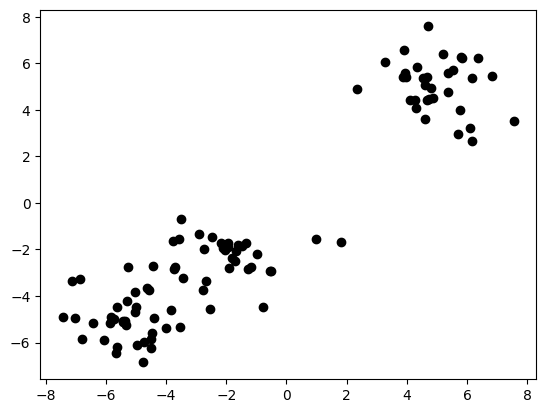

In [39]:
plt.scatter(X[:,0],X[:,1],c='black',marker='o')
plt.show()

In [40]:
import numpy as np
import random

class KMeansfromscratch:

    def __init__(self, n_clusters=2, max_iterations=100):
        self.n_clusters = n_clusters
        self.max_iterations = max_iterations
        self.centroids = None

    def fit_predict(self, X):

        # Choosing random points as initial centroids
        random_index = random.sample(
            range(X.shape[0]),
            self.n_clusters
        )

        self.centroids = X[random_index]

        for i in range(self.max_iterations):

            # Assign each point to a cluster
            clusters = self.create_clusters(X)

            # Save previous centroids
            previous_centroids = self.centroids.copy()

            # Move centroids
            self.centroids = self.move_cluster(X, clusters)

            # Check convergence
            if np.array_equal(previous_centroids, self.centroids):
                break

        return clusters

    def create_clusters(self, X):

        clusters = []

        for row in X:

            distances = []

            for centroid in self.centroids:

                distance = np.sqrt(
                    np.dot(row - centroid, row - centroid)
                )

                distances.append(distance)

            min_index = distances.index(min(distances))

            clusters.append(min_index)

        return np.array(clusters)

    def move_cluster(self, X, cluster_group):

        new_centroids = []

        for cluster_number in range(self.n_clusters):

            # Get points belonging to this cluster
            cluster_points = X[cluster_group == cluster_number]

            # If cluster has no points, keep old centroid
            if len(cluster_points) == 0:
                new_centroids.append(self.centroids[cluster_number])
            else:
                new_centroids.append(
                    cluster_points.mean(axis=0)
                )

        return np.array(new_centroids)




In [41]:
km=KMeansfromscratch(n_clusters=3,max_iterations=100)
y_means=km.fit_predict(X)
print(y_means)

[1 2 1 2 0 1 1 2 1 0 0 0 1 0 0 0 2 2 2 1 2 2 0 0 0 1 0 1 2 0 0 2 1 1 1 1 0
 2 0 0 1 1 2 2 2 2 0 1 0 0 1 2 2 2 2 2 2 2 2 1 2 1 1 2 0 1 0 2 1 1 0 1 1 2
 2 2 1 2 0 2 0 0 0 1 0 1 1 0 2 1 0 2 1 0 0 1 0 1 1 0]


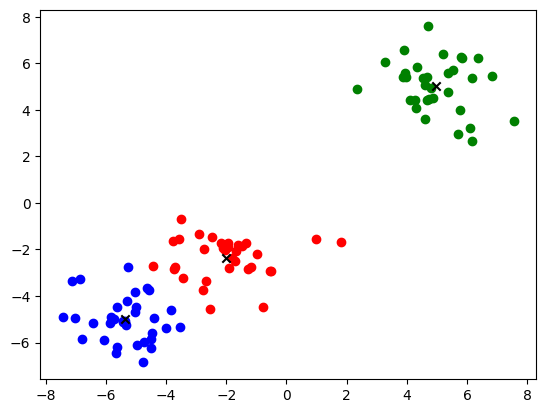

In [43]:
plt.scatter(X[y_means == 0,0],X[y_means == 0,1],color='red')
plt.scatter(X[y_means == 1,0],X[y_means == 1,1],color='blue')
plt.scatter(X[y_means == 2,0],X[y_means == 2,1],color='green')
plt.scatter(km.centroids[:,0],km.centroids[:,1],color='black',marker='x')
plt.show()
#